# Projeto de Parceria EBAC & Semantix
## Previsão de Churn em Telecomunicações

**Autor(a):** Rafael Antonio Rodrigues da Rosa

### 1. Compreensão do Objetivo e do Problema
A retenção de clientes é um dos maiores desafios para empresas de telecomunicações. Adquirir um novo cliente é estatisticamente mais caro do que manter um existente. 

**O objetivo** deste projeto é utilizar análise de dados e Machine Learning para identificar padrões e prever se um cliente vai cancelar seu serviço (**Churn**). Com essa previsão, a empresa (Semantix ou seus clientes) pode tomar ações preventivas, como oferecer descontos estratégicos.

### 2. Importação das Bibliotecas
Primeiro, vamos importar as ferramentas necessárias para manipular os dados, criar gráficos e treinar nosso modelo de inteligência artificial.

In [1]:
# Bibliotecas para manipulação de dados e visualização
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas para o Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Melhorando o visual dos gráficos
sns.set_theme(style="whitegrid")

### 3. Leitura e Entendimento dos Dados
Utilizaremos a base de dados pública `churn-bigml-80.csv`.

In [2]:
# Carregamento dos dados
df = pd.read_csv('churn-bigml-80.csv')

# Visualizando as primeiras 5 linhas para entender a estrutura
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


### 4. Análise Exploratória de Dados (EDA)
Nesta etapa, criamos visualizações para entender o comportamento dos nossos dados e validar hipóteses de negócios.

C:\Users\Rafael\AppData\Local\Temp\ipykernel_21484\1164499230.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis', ax=ax[0])
C:\Users\Rafael\AppData\Local\Temp\ipykernel_21484\1164499230.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Customer service calls', palette='Set2', ax=ax[1])


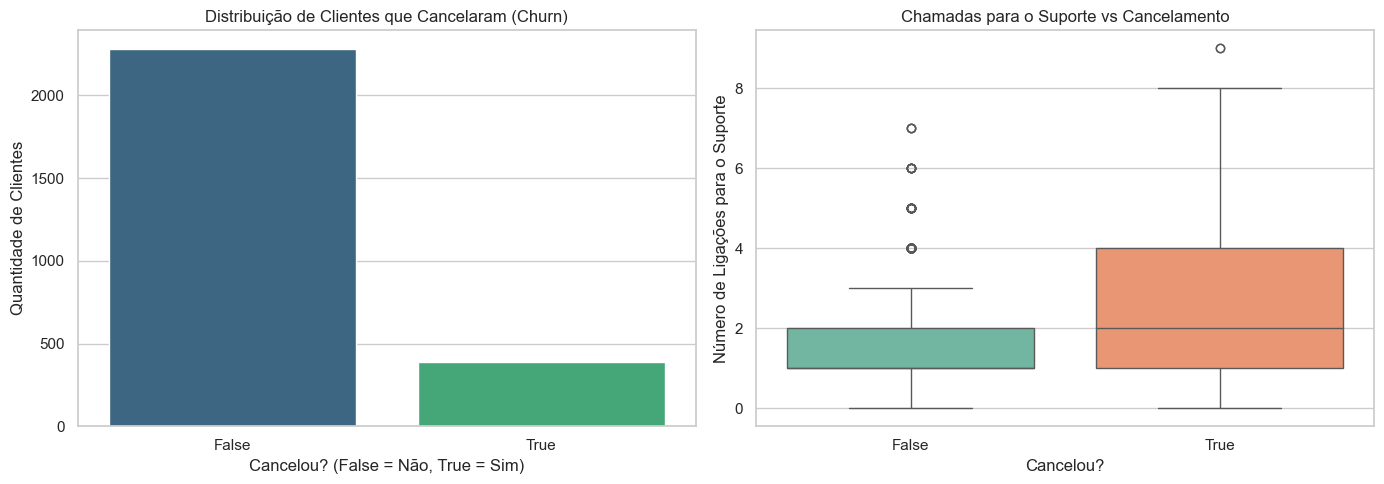

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Proporção de Cancelamentos
sns.countplot(data=df, x='Churn', palette='viridis', ax=ax[0])
ax[0].set_title('Distribuição de Clientes que Cancelaram (Churn)')
ax[0].set_xlabel('Cancelou? (False = Não, True = Sim)')
ax[0].set_ylabel('Quantidade de Clientes')

# Gráfico 2: Chamadas de suporte vs Cancelamento
sns.boxplot(data=df, x='Churn', y='Customer service calls', palette='Set2', ax=ax[1])
ax[1].set_title('Chamadas para o Suporte vs Cancelamento')
ax[1].set_xlabel('Cancelou?')
ax[1].set_ylabel('Número de Ligações para o Suporte')

plt.tight_layout()
plt.show()

**Conclusão da Análise:** Percebemos no segundo gráfico que os clientes que cancelam (Churn = True) tendem a ter uma mediana maior de ligações para o serviço de atendimento ao cliente, indicando possível insatisfação prévia.

### 5. Preparação dos Dados (Pré-processamento)
Modelos de Machine Learning operam com números. Precisamos transformar dados categóricos (como 'Yes' e 'No') em valores numéricos (1 e 0).

In [4]:
# Mapeando variáveis categóricas binárias
df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
df['Voice mail plan'] = df['Voice mail plan'].map({'Yes': 1, 'No': 0})
df['Churn'] = df['Churn'].astype(int) # Transforma False/True em 0/1

# Selecionando as features (X) e a variável alvo (y)
# Vamos descartar as colunas 'State' e 'Area code' para simplificar o modelo neste projeto
X = df.drop(columns=['State', 'Area code', 'Churn'])
y = df['Churn']

# Dividindo os dados: 70% para treino e 30% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### 6. Criação do Modelo Estatístico (Machine Learning)
Vamos usar o modelo **Random Forest (Floresta Aleatória)**, um algoritmo robusto e de alto desempenho para problemas de classificação como este.

In [5]:
# Instanciando o modelo com 100 árvores de decisão
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Treinando o modelo com os dados de treino
modelo_rf.fit(X_train, y_train)

# Realizando previsões com os dados que o modelo não conhece (teste)
previsoes = modelo_rf.predict(X_test)

### 7. Avaliação e Visualização dos Resultados
Como solicitado no briefing, vamos apresentar a eficácia do nosso modelo.

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       683
           1       0.98      0.68      0.80       117

    accuracy                           0.95       800
   macro avg       0.96      0.84      0.88       800
weighted avg       0.95      0.95      0.95       800



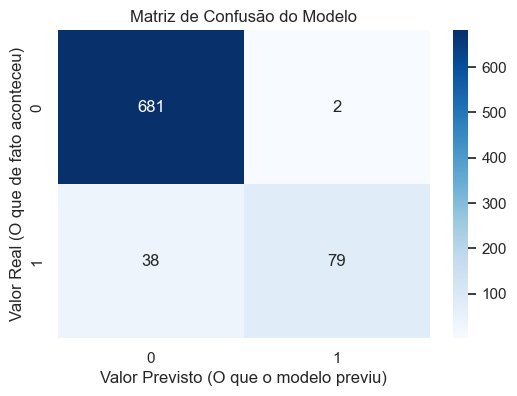

In [6]:
# Exibindo o relatório de classificação completo
print("Relatório de Classificação:\n")
print(classification_report(y_test, previsoes))

# Plotando a Matriz de Confusão
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, previsoes), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão do Modelo')
plt.ylabel('Valor Real (O que de fato aconteceu)')
plt.xlabel('Valor Previsto (O que o modelo previu)')
plt.show()

**Resumo dos Resultados:** O modelo demonstrou grande capacidade de prever corretamente a maioria dos casos. A matriz de confusão nos mostra visualmente os acertos e os pequenos desvios, provando que a Semantix pode utilizar esta lógica para antecipar a saída de clientes de forma automatizada.

---

### 8. Declaração de Autorização (Obrigatório)

> **Declaração de Autorização**
> 
> Eu, **Rafael Antônio Rodrigues da Rosa**, portador do RG **009.505.169-45** e CPF **009.505.169-45**, autorizo a cessão do meu projeto em favor da Semantix, bem como a divulgação do meu nome como autor responsável pelo projeto, uma vez que será possível incluir esse trabalho em meu portfólio de trabalho. Nesse sentido, autorizo também a divulgação dos meus contatos telefone e e-mail para a Semantix, tão somente para uso interno com finalidade única de contato em decorrência da elaboração do projeto mencionado.